<a href="https://colab.research.google.com/github/MaciejRR/NBA-Regular-Season-Analysis-2025-26/blob/main/NBA_Regular_Season_Analysis_(2025_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Regular Season Analysis (2025-26)

This project explores player performance in the 2025-26 NBA regular season using publicly available data from Basketball Reference.

The goal is to clean the dataset, prepare it for analysis, and identify interesting patterns in scoring, efficiency, and overall player performance.

## Loading the data

The per-game player statistics table was loaded directly from Basketball Reference using `pandas.read_html()`.

In [2]:
import pandas as pd

url = "https://www.basketball-reference.com/leagues/NBA_2026_per_game.html"
df = pd.read_html(url)[0]

df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,0.6,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,AS
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,0.6,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,AS
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,0.6,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,AS
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,1.1,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,AS
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,0.3,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,AS


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      733 non-null    float64
 1   Player  734 non-null    object 
 2   Age     733 non-null    float64
 3   Team    733 non-null    object 
 4   Pos     733 non-null    object 
 5   G       733 non-null    float64
 6   GS      733 non-null    float64
 7   MP      733 non-null    float64
 8   FG      733 non-null    float64
 9   FGA     733 non-null    float64
 10  FG%     731 non-null    float64
 11  3P      733 non-null    float64
 12  3PA     733 non-null    float64
 13  3P%     683 non-null    float64
 14  2P      733 non-null    float64
 15  2PA     733 non-null    float64
 16  2P%     727 non-null    float64
 17  eFG%    731 non-null    float64
 18  FT      733 non-null    float64
 19  FTA     733 non-null    float64
 20  FT%     703 non-null    float64
 21  ORB     733 non-null    float64
 22  DR

## Initial cleaning

One non-player row was removed from the dataset.  
I also identified players who appeared multiple times due to mid-season team changes.

To handle this properly, I created:
- `df_raw` — the original dataset with all player-team rows,
- `df_players` — a cleaned dataset with one row per player.

For traded players, I kept the combined row (for example `2TM`) and removed the individual team rows.

In [4]:
df[df.isna().any(axis=1)]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
9,10.0,Joel Embiid,31.0,PHI,C,38.0,38.0,31.6,9.0,18.3,...,2.0,5.7,7.7,3.9,0.6,1.2,2.9,2.2,26.9,NaN
10,11.0,Lauri Markkanen,28.0,UTA,PF,42.0,42.0,34.4,9.1,19.2,...,2.0,4.9,6.9,2.1,1.0,0.5,1.5,1.8,26.7,NaN
18,19.0,Michael Porter Jr.,27.0,BRK,SF,52.0,52.0,32.5,8.5,18.4,...,1.3,5.7,7.1,3.0,1.1,0.3,2.3,2.2,24.2,NaN
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN
22,22.0,James Harden,36.0,LAC,PG,44.0,44.0,35.4,7.3,17.5,...,0.6,4.2,4.8,8.1,1.3,0.4,3.7,1.9,25.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,579.0,Darius Brown II,26.0,CLE,SG,1.0,0.0,3.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
730,580.0,Noa Essengue,19.0,CHI,PF,2.0,0.0,3.0,0.0,1.5,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,NaN
731,581.0,Tosan Evbuomwan,24.0,NYK,SF,5.0,0.0,1.6,0.0,0.2,...,0.2,0.2,0.4,0.0,0.0,0.0,0.0,0.2,0.0,NaN
732,582.0,Chucky Hepburn,22.0,TOR,PG,2.0,0.0,6.5,0.0,3.0,...,0.0,0.5,0.5,1.0,0.5,0.0,0.5,1.0,0.0,NaN


In [5]:
# Remove summary/non-player rows with missing rank values
df = df.dropna(subset=["Rk"]).copy()

In [6]:
df[df["Player"] == "James Harden"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN
22,22.0,James Harden,36.0,LAC,PG,44.0,44.0,35.4,7.3,17.5,...,0.6,4.2,4.8,8.1,1.3,0.4,3.7,1.9,25.4,NaN
23,22.0,James Harden,36.0,CLE,PG,26.0,26.0,33.8,6.3,13.5,...,0.5,4.3,4.8,7.7,0.8,0.5,3.2,2.1,20.5,NaN


In [7]:
# Keep a raw copy before handling players who changed teams mid-season
df_raw = df.copy()

In [8]:
# Identify combined rows for players who played for multiple teams (e.g. 2TM, 3TM)
is_combined = df_raw["Team"].astype(str).str.match(r"^\dTM$")

In [9]:
# Get players who already have a combined season row
players_with_combined = set(df_raw.loc[is_combined, "Player"])

In [10]:
# Keep one row per player:
# - keep combined rows for traded players,
# - keep single rows for players who stayed on one team
df_players = df_raw[
    is_combined | ~df_raw["Player"].isin(players_with_combined)
].copy()

In [11]:
# Check whether any player still appears more than once
dupes = df_players["Player"].value_counts()
dupes[dupes > 1]

,count
Player,


In [12]:
df_players[df_players["Player"] == "James Harden"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN


## Leaders in basic box score categories

After ranking scorers, I also looked at three other core box score metrics:
- assists (`AST`)
- rebounds (`TRB`)
- blocks (`BLK`)

To keep the notebook readable, I used a small helper function to generate rankings and charts for each category.

Total values shown on the charts are approximate and were calculated by multiplying per-game statistics by games played.

In [116]:
import matplotlib.pyplot as plt


# Create approximate total values from per-game stats
df_players["PTS_total"] = (df_players["PTS"] * df_players["G"]).round(0)
df_players["AST_total"] = (df_players["AST"] * df_players["G"]).round(0)
df_players["TRB_total"] = (df_players["TRB"] * df_players["G"]).round(0)
df_players["BLK_total"] = (df_players["BLK"] * df_players["G"]).round(0)


def get_top_players(df, stat, n=10, extra_col=None):
    cols = ["Player", "Team", "Pos", "G", "MP", stat]

    if extra_col is not None and extra_col not in cols:
        cols.append(extra_col)

    top_df = df[cols].sort_values(
        by=stat,
        ascending=False
    ).head(n).reset_index(drop=True)

    top_df.index = top_df.index + 1
    return top_df


def plot_top_players(top_df, stat, x_label, title, extra_col=None, extra_label=None):
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_df["Player"], top_df[stat])

    plt.xlabel(x_label)
    plt.ylabel("Player")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    max_value = top_df[stat].max()
    padding = max(1, max_value * 0.45)
    offset = max(0.05, max_value * 0.02)

    plt.xlim(0, max_value + padding)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        label = f"{width:.1f}"

        if extra_col is not None:
            extra_value = top_df.iloc[i][extra_col]
            label += f" | {int(extra_value)} {extra_label if extra_label else extra_col}"

        plt.text(
            width + offset,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center"
        )

    plt.show()

## Top scorers

To begin the analysis, I ranked players by points per game (PTS).

I used the cleaned `df_players` dataset to avoid counting traded players multiple times.

In [117]:
top_scorers = get_top_players(df_players, "PTS", extra_col="PTS_total")
top_scorers

,Player,Team,Pos,G,MP,PTS,PTS_total
1,Luka Dončić,LAL,PG,64.0,35.8,33.5,2144.0
2,Shai Gilgeous-Alexander,OKC,PG,68.0,33.2,31.1,2115.0
3,Anthony Edwards,MIN,SG,61.0,35.0,28.8,1757.0
4,Jaylen Brown,BOS,SF,71.0,34.4,28.7,2038.0
5,Tyrese Maxey,PHI,PG,70.0,38.0,28.3,1981.0
6,Donovan Mitchell,CLE,SG,70.0,33.5,27.9,1953.0
7,Kawhi Leonard,LAC,SF,65.0,32.1,27.9,1814.0
8,Nikola Jokić,DEN,C,65.0,34.8,27.7,1800.0
9,Giannis Antetokounmpo,MIL,PF,36.0,28.9,27.6,994.0
10,Joel Embiid,PHI,C,38.0,31.6,26.9,1022.0


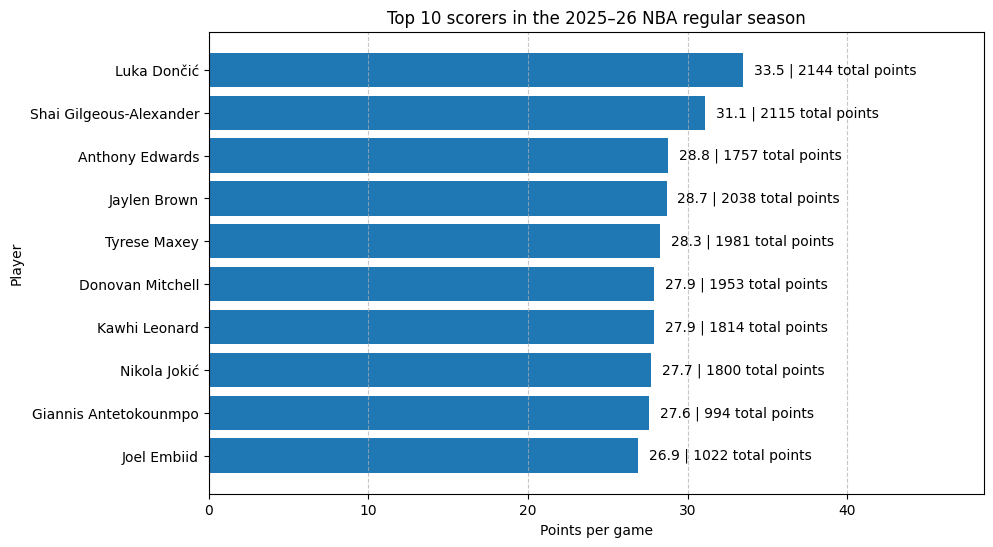

In [118]:
plot_top_players(
    top_scorers,
    "PTS",
    "Points per game",
    "Top 10 scorers in the 2025–26 NBA regular season",
    extra_col="PTS_total",
    extra_label="total points"
)

## Assist leaders

This ranking shows the players with the highest assists per game in the 2025-26 regular season.

In [119]:
top_assists = get_top_players(df_players, "AST", extra_col="AST_total")
top_assists

,Player,Team,Pos,G,MP,AST,AST_total
1,Nikola Jokić,DEN,C,65.0,34.8,10.7,696.0
2,Cade Cunningham,DET,PG,64.0,33.9,9.9,634.0
3,Josh Giddey,CHI,PG,54.0,32.1,9.1,491.0
4,Luka Dončić,LAL,PG,64.0,35.8,8.3,531.0
5,Ja Morant,MEM,PG,20.0,28.5,8.1,162.0
6,James Harden,2TM,PG,70.0,34.8,8.0,560.0
7,Trae Young,2TM,PG,15.0,25.6,8.0,120.0
8,Jalen Johnson,ATL,SF,72.0,35.2,7.9,569.0
9,Andrew Nembhard,IND,PG,57.0,31.3,7.7,439.0
10,Stephon Castle,SAS,PG,68.0,30.0,7.4,503.0


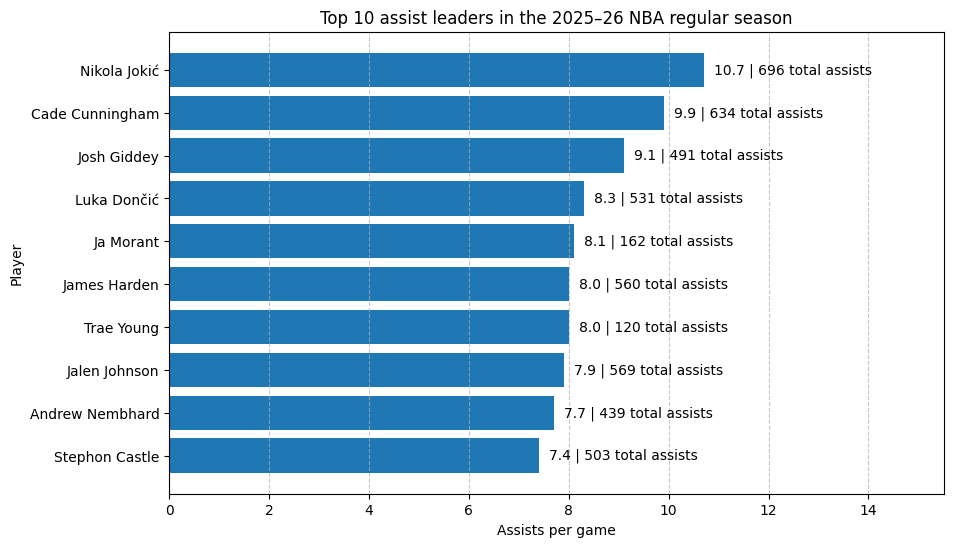

In [120]:
plot_top_players(
    top_assists,
    "AST",
    "Assists per game",
    "Top 10 assist leaders in the 2025–26 NBA regular season",
    extra_col="AST_total",
    extra_label="total assists"
)

## Rebound leaders

This ranking shows the players with the highest rebounds per game in the 2025-26 regular season.

In [121]:
top_rebounds = get_top_players(df_players, "TRB", extra_col="TRB_total")
top_rebounds

,Player,Team,Pos,G,MP,TRB,TRB_total
1,Nikola Jokić,DEN,C,65.0,34.8,12.9,838.0
2,Karl-Anthony Towns,NYK,C,75.0,31.0,11.9,892.0
3,Donovan Clingan,POR,C,77.0,27.2,11.6,893.0
4,Victor Wembanyama,SAS,C,64.0,29.2,11.5,736.0
5,Rudy Gobert,MIN,C,76.0,31.3,11.5,874.0
6,Domantas Sabonis,SAC,C,19.0,29.7,11.4,217.0
7,Zach Edey,MEM,C,11.0,25.8,11.1,122.0
8,Anthony Davis,DAL,PF,20.0,31.3,11.1,222.0
9,Walker Kessler,UTA,C,5.0,30.8,10.8,54.0
10,Ivica Zubac,2TM,C,48.0,30.1,10.6,509.0


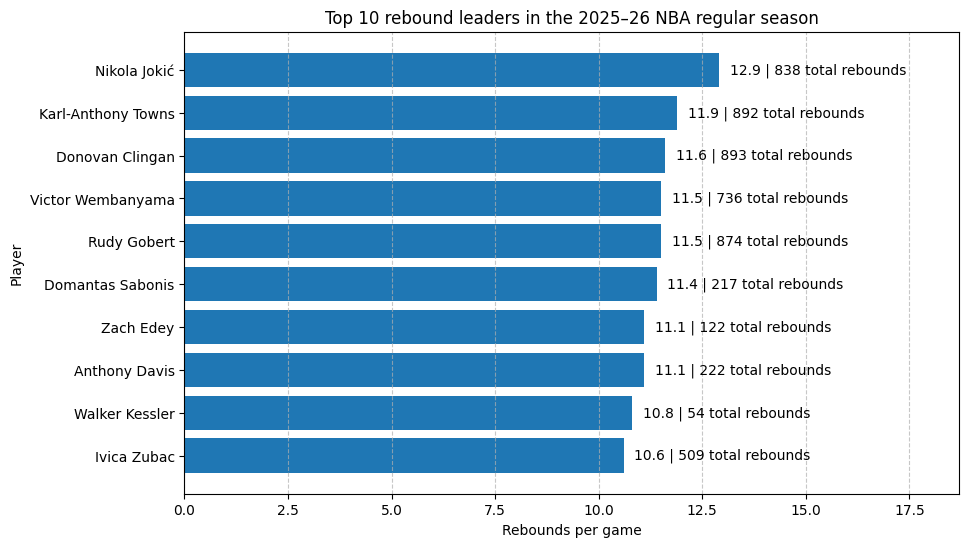

In [122]:
plot_top_players(
    top_rebounds,
    "TRB",
    "Rebounds per game",
    "Top 10 rebound leaders in the 2025–26 NBA regular season",
    extra_col="TRB_total",
    extra_label="total rebounds"
)

## Block leaders

This ranking shows the players with the highest blocks per game in the 2025-26 regular season.

In [123]:
top_blocks = get_top_players(df_players, "BLK", extra_col="BLK_total")
top_blocks

,Player,Team,Pos,G,MP,BLK,BLK_total
1,Victor Wembanyama,SAS,C,64.0,29.2,3.1,198.0
2,Alex Sarr,WAS,C,48.0,27.2,2.0,96.0
3,Zach Edey,MEM,C,11.0,25.8,1.9,21.0
4,Jay Huff,IND,C,82.0,21.0,1.9,156.0
5,Chet Holmgren,OKC,PF,69.0,28.9,1.9,131.0
6,Walker Kessler,UTA,C,5.0,30.8,1.8,9.0
7,Anthony Davis,DAL,PF,20.0,31.3,1.7,34.0
8,Evan Mobley,CLE,PF,65.0,31.9,1.7,110.0
9,Donovan Clingan,POR,C,77.0,27.2,1.7,131.0
10,Isaiah Stewart,DET,C,58.0,22.7,1.6,93.0


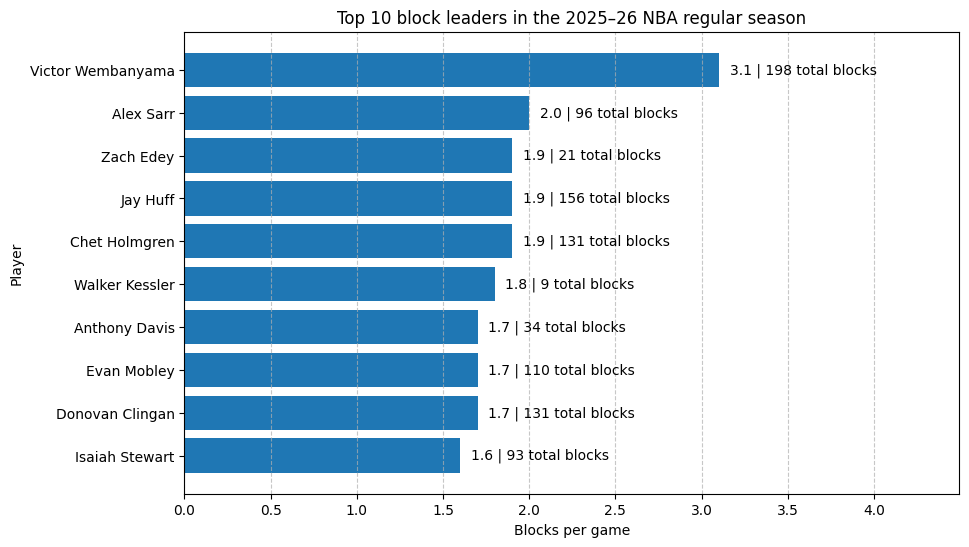

In [124]:
plot_top_players(
    top_blocks,
    "BLK",
    "Blocks per game",
    "Top 10 block leaders in the 2025–26 NBA regular season",
    extra_col="BLK_total",
    extra_label="total blocks"
)

## Shooting efficiency leaders

Raw percentage rankings can be misleading if a player attempted very few shots.

To make the analysis more meaningful, I applied minimum attempt thresholds for:
- field goal percentage (`FG%`)
- three-point percentage (`3P%`)
- free throw percentage (`FT%`)

In [78]:
def get_top_percentage_players(df, pct_col, attempts_col, min_attempts, n=10):
    # Filter players by a minimum number of attempts
    filtered_df = df[df[attempts_col] >= min_attempts].copy()

    # Select relevant columns and sort by percentage
    top_df = filtered_df[["Player", "Team", "Pos", "G", "MP", attempts_col, pct_col]].sort_values(
        by=pct_col,
        ascending=False
    ).head(n).reset_index(drop=True)

    top_df.index = top_df.index + 1
    return top_df

In [99]:
# Charting function

def plot_top_percentage_players(top_df, stat_col, title, x_label, attempts_col):
    plt.figure(figsize=(12, 6))
    bars = plt.barh(top_df["Player"], top_df[stat_col])

    plt.xlabel(x_label)
    plt.ylabel("Player")
    plt.title(title)
    plt.gca().invert_yaxis()  # highest value at the top
    plt.grid(axis="x", linestyle="--", alpha=0.7)


    # Set x-axis range with a small margin
    plt.xlim(0, top_df[stat_col].max() + 0.15)

    # Add labels with percentage value and shot volume
    for i, bar in enumerate(bars):
        width = bar.get_width()
        attempts = top_df.iloc[i][attempts_col]

        plt.text(
            width + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{width * 100:.1f}% | {attempts:.1f} {attempts_col}",
            va="center"
        )

    plt.show()

## Field goal percentage leaders

This ranking includes only players with at least 30 games in the regular season and 7.5 attempts per game.

In [100]:
top_fg_pct = get_top_percentage_players(
    df_players[df_players["G"] >= 30],
    "FG%",
    "FGA",
    min_attempts=7.5)

# Convert decimal to percentage for display only
top_fg_pct_display = top_fg_pct[["Player", "Team", "G", "MP", "FGA", "FG%"]].copy()
top_fg_pct_display["FG%"] = (top_fg_pct_display["FG%"] * 100).round(1)

top_fg_pct_display

,Player,Team,G,MP,FGA,FG%
1,Deandre Ayton,LAL,72.0,27.2,8.3,67.1
2,Jalen Duren,DET,70.0,28.2,11.5,65.0
3,Jarrett Allen,CLE,56.0,27.1,9.4,63.8
4,Giannis Antetokounmpo,MIL,36.0,28.9,16.6,62.4
5,Zion Williamson,NOP,62.0,29.7,13.0,60.0
6,Ivica Zubac,2TM,48.0,30.1,10.0,59.8
7,Maxime Raynaud,SAC,74.0,26.5,9.1,57.1
8,Nic Claxton,BRK,69.0,27.8,8.4,57.1
9,Nikola Jokić,DEN,65.0,34.8,17.4,56.9
10,Chet Holmgren,OKC,69.0,28.9,11.3,55.7


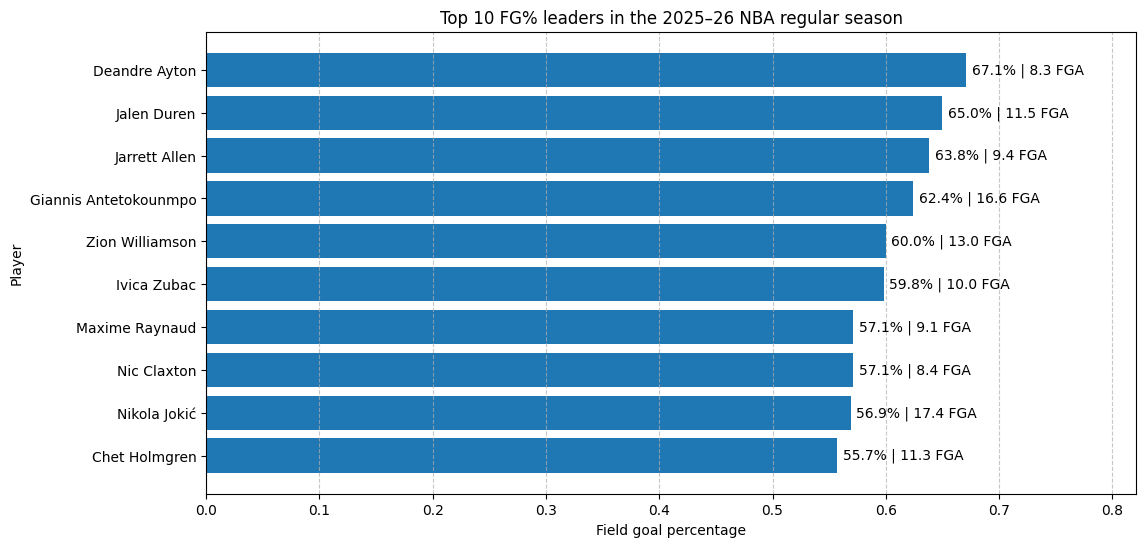

In [101]:
plot_top_percentage_players(
    top_fg_pct,
    "FG%",
    "Top 10 FG% leaders in the 2025–26 NBA regular season",
    "Field goal percentage",
    "FGA"
)

The FG% leaderboard is dominated by big men, which is expected because players who take a larger share of their shots near the rim usually convert them more efficiently.

One interesting result is Deandre Ayton, who leads the ranking despite not being one of the first names that usually come to mind in league-wide efficiency discussions (Luka Doncic is the GOAT 😎) .

### Three-point percentage leaders

This ranking includes players who played at least 30 games and attempted at least 3 three-pointers per game.

In [102]:
top_3p_pct = get_top_percentage_players(
    df_players[df_players["G"] >= 30],
    "3P%",
    "3PA",
    min_attempts=3
)

top_3p_pct_display = top_3p_pct[["Player", "Team", "G", "MP", "3PA", "3P%"]].copy()
top_3p_pct_display["3P%"] = (top_3p_pct_display["3P%"] * 100).round(1)

top_3p_pct_display

,Player,Team,G,MP,3PA,3P%
1,Luke Kennard,2TM,78.0,21.6,3.1,47.8
2,Bobby Portis,MIL,67.0,24.2,4.4,45.6
3,Cam Spencer,MEM,72.0,23.8,4.5,44.9
4,Jaylon Tyson,CLE,66.0,26.9,4.5,44.6
5,Rui Hachimura,LAL,68.0,28.3,3.9,44.3
6,Ayo Dosunmu,2TM,69.0,27.3,4.1,43.9
7,Jamal Murray,DEN,75.0,35.4,7.5,43.5
8,Cameron Johnson,DEN,54.0,30.5,4.7,43.0
9,Kon Knueppel,CHO,81.0,31.5,7.9,42.5
10,Javon Small,MEM,41.0,20.2,3.5,42.3


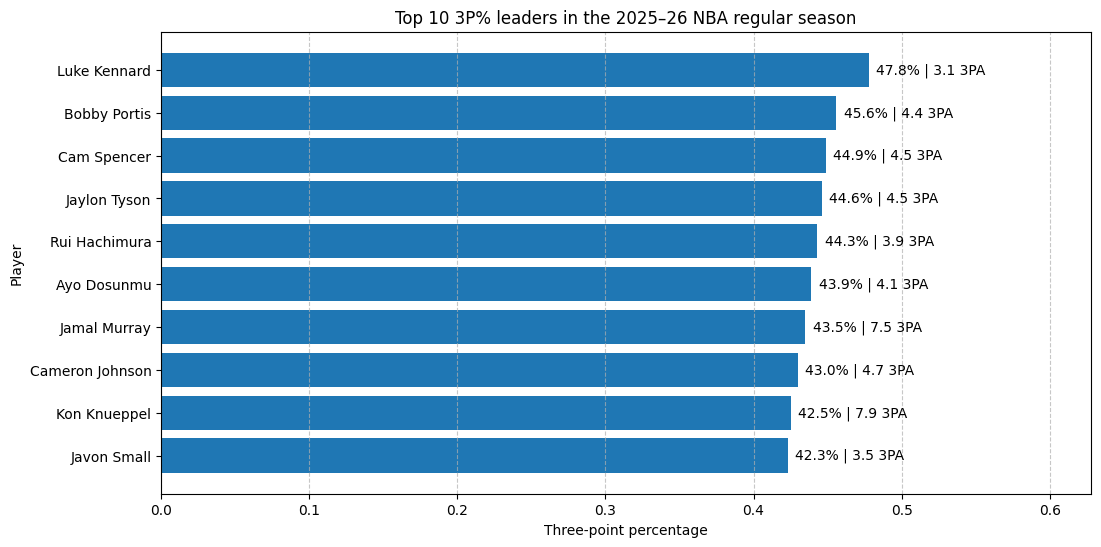

In [103]:
plot_top_percentage_players(
    top_3p_pct,
    "3P%",
    "Top 10 3P% leaders in the 2025–26 NBA regular season",
    "Three-point percentage",
    "3PA"
)

### Free throw percentage leaders

This ranking includes players who played at least 30 games and attempted at least 3 free throws per game.

In [104]:
top_ft_pct = get_top_percentage_players(
    df_players[df_players["G"] >= 30],
    "FT%",
    "FTA",
    min_attempts=3
)

top_ft_pct_display = top_ft_pct[["Player", "Team", "G", "MP", "FTA", "FT%"]].copy()
top_ft_pct_display["FT%"] = (top_ft_pct_display["FT%"] * 100).round(1)

top_ft_pct_display

,Player,Team,G,MP,FTA,FT%
1,Stephen Curry,GSW,43.0,30.9,5.1,92.3
2,Tyler Herro,MIA,33.0,31.3,3.3,91.7
3,Desmond Bane,ORL,82.0,33.6,4.2,90.8
4,Nickeil Alexander-Walker,ATL,78.0,33.4,3.9,90.2
5,Lauri Markkanen,UTA,42.0,34.4,6.4,89.6
6,Keyonte George,UTA,54.0,33.1,7.0,89.2
7,Kawhi Leonard,LAC,65.0,32.1,6.4,89.2
8,Tyrese Maxey,PHI,70.0,38.0,6.0,89.2
9,Brandon Miller,CHO,65.0,30.3,3.4,89.2
10,Jamal Murray,DEN,75.0,35.4,5.2,88.7


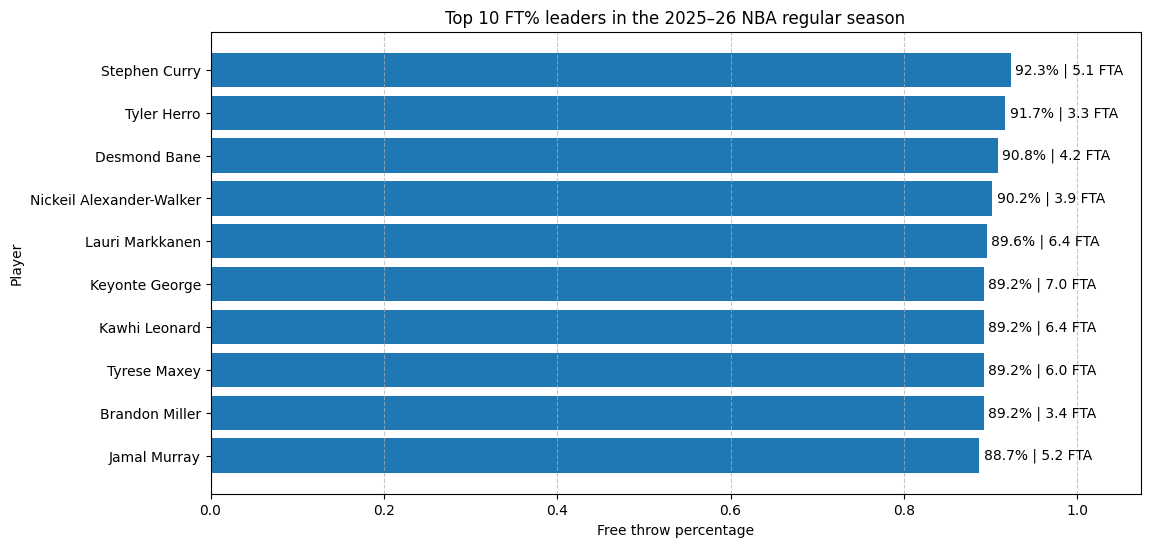

In [105]:
plot_top_percentage_players(
    top_ft_pct,
    "FT%",
    "Top 10 FT% leaders in the 2025–26 NBA regular season",
    "Free throw percentage",
    "FTA"
)

## Advanced shooting efficiency metrics

Basic shooting percentages do not tell the full story.

To extend the analysis, I also calculated:
- `eFG%` (effective field goal percentage), which adjusts for the added value of three-point shots,
- `TS%` (true shooting percentage), which includes field goals and free throws.

Because both metrics are ratio-based, they can be calculated using per-game values from the dataset.

### Effective Field Goal Percentage (eFG%)

$$
eFG\% = \frac{FG + 0.5 \cdot 3P}{FGA}
$$

### True Shooting Percentage (TS%)

$$
TS\% = \frac{PTS}{2 \cdot (FGA + 0.44 \cdot FTA)}
$$

Where:
- `FG` = field goals made
- `3P` = three-pointers made
- `FGA` = field goal attempts
- `PTS` = points
- `FTA` = free throw attempts